In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_0): ")

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
# from lib.visualization.distribution_collector import collect_top_bottom_tags
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Bold Oblique.ttf
Registered font name: Helvetica


In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/code_complexity/{visualization_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'


std_date = Date_Setting[option_dict['year_range']]['std_date']

[Deleteing... ] ./fig/


In [5]:
origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])
origin_df = origin_df[['id', 'creationdate']]

100%|██████████| 65/65 [00:12<00:00,  5.11it/s]


In [6]:
df = pd.read_parquet(f'{option_dict["save_dir"]}/data/all_complexity.parquet')

In [32]:
df['id'] = df['Path'].apply(lambda x : x.split('_')[1].split('.')[0])
df[['id', 'Cognitive Complexity']] = df[['id', 'Cognitive Complexity']].astype(int)

In [33]:
viz_df = pd.merge(df, origin_df, on = 'id', how='left')[['id', 'creationdate', 'Cognitive Complexity']]

In [34]:
viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- std_date).dt.days/7)

In [20]:
print(viz_df['rel_week'].min())
print(viz_df['rel_week'].max())

-104.0
155.0


In [ ]:
# viz_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247753 entries, 0 to 247752
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    247753 non-null  int64  
 1   creationdate          247753 non-null  object 
 2   Cognitive Complexity  247753 non-null  int64  
 3   rel_week              247753 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 7.6+ MB


In [ ]:
# viz_df = (viz_df.groupby(['id','rel_week'], as_index=False)['Cognitive Complexity'].max()
#                 .groupby('rel_week', as_index=False)['Cognitive Complexity'].mean())

In [ ]:
viz_df = (viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].mean())

In [36]:
viz_df[viz_df['rel_week'] == 0].index.values[0]

np.int64(104)

In [ ]:
# viz_df = viz_df[viz_df['rel_week']<104]

In [37]:
st_chow_1year = st.Stats(viz_df['rel_week'].values, viz_df['Cognitive Complexity'].values, 2, 0.95, viz_df[viz_df['rel_week'] == 0].index.values[0])
F_stat_1, p_value_1 = st_chow_1year.chow_test()


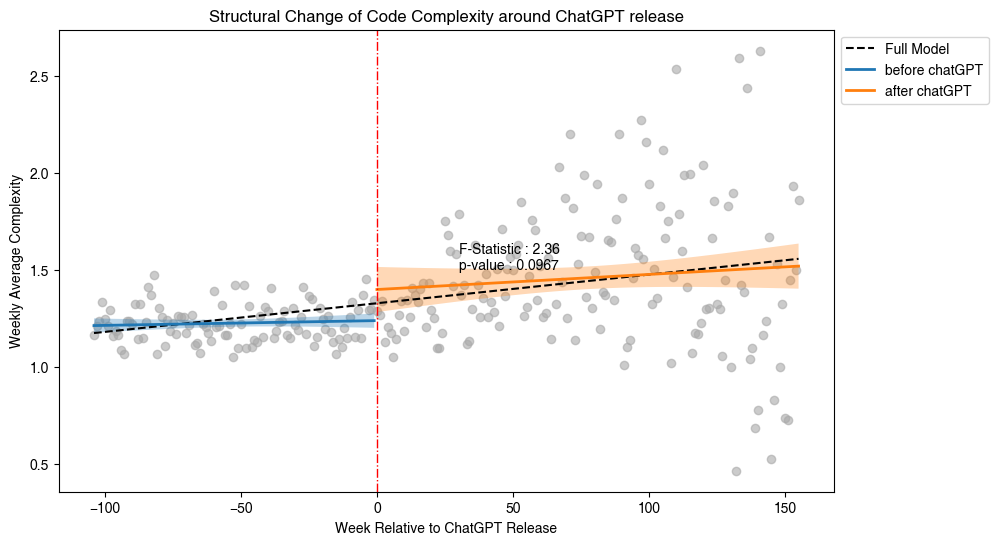

In [38]:
x = viz_df['rel_week'].values
y = viz_df['Cognitive Complexity'].values

split_idx = np.argmax(np.where(x < 0))+1
x1= x[:split_idx]
x2= x[split_idx:]
# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(x, y,  alpha=0.6, color='darkgray')
plt.plot(x, st_chow_1year.y_predict, label="Full Model", linestyle="--", color="black")  


plt.plot(x1, st_chow_1year.y1_predict, label="before chatGPT", linewidth='2')
plt.fill_between(x1, st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval, st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval, alpha=0.3)

plt.plot(x2, st_chow_1year.y2_predict, label="after chatGPT", linewidth='2')
plt.fill_between(x2, st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval, st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval, alpha=0.3)

plt.text(30, 1.5, s=f'F-Statistic : {F_stat_1:.2f}\np-value : {p_value_1:.4f}', fontsize = 10) #
plt.axvline(x=0,     color='red',    linestyle='-.', linewidth=1)

plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.title(f"Structural Change of Code Complexity around ChatGPT release")
plt.xlabel("Week Relative to ChatGPT Release")
plt.ylabel("Weekly Average Complexity")
plt.savefig("complexity_chow_ver3.png", dpi=300, bbox_inches='tight')  # DPI 설정 및 여백 최소화
plt.show()
